## Import Supporting Libraries

In [6]:
import warnings
warnings.filterwarnings('ignore')
from ultralytics import YOLO
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from tkinter.filedialog import askopenfilename
from matplotlib import pyplot as plt
%matplotlib inline

## Loading Detector, Feature Extractor and our Trained Model

In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
scaler = StandardScaler()

model = YOLO("yolo11n-seg.pt")
FM = pd.read_csv('HOG_FM.csv')
X,Y = FM.iloc[:,:-2].values,FM.iloc[:,-2]
lda = LDA(n_components=106)
def HOG(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return hog(gray, orientations=8, pixels_per_cell=(32, 32),cells_per_block=(2, 2), visualize=False)
rmodel =OneVsRestClassifier(SVC(kernel="rbf")).fit(lda.fit_transform(scaler.fit_transform(X),Y),Y)  

## Defined Relavent Funtions

In [8]:
def Classify(path):
    im = cv2.imread(path)
    Img = cv2.resize(im,(256,256))
    return rmodel.predict(lda.transform(scaler.transform([HOG(Img).tolist()])))[0]

def segment(Im,Rm):
    temp = Im.copy()
    for j in range(temp.shape[2]):
        temp[:,:,j] = temp[:,:,j]*Rm[:,:,j]
    return temp
    
def predict(impt):
    results = model([impt],verbose=False) 
    bbx = []
    pre = []
    for r in results:
        img = np.copy(r.orig_img)
        mms=[]
        for c in r:
            b_mask = np.zeros(img.shape[:2], np.uint8)
            contour = c.masks.xy.pop().astype(np.int32).reshape(-1, 1, 2)
            _ = cv2.drawContours(b_mask, [contour], -1, (255, 255, 255), cv2.FILLED)
            mask3ch = cv2.cvtColor(b_mask, cv2.COLOR_GRAY2BGR)
            mms.append(mask3ch//np.max(mask3ch))
            isolated = segment(r.orig_img,mask3ch//np.max(mask3ch))
            x1, y1, x2, y2 = c.boxes.xyxy.cpu().numpy().squeeze().astype(np.int32)
            bbx.append([x1, y1, x2, y2])
            cv2.imwrite('crop.jpg',isolated[y1:y2, x1:x2])
            pre.append(Classify('crop.jpg'))
            
        if len(mms)>1:
            a = mms[0]
            for m in mms[1:]:
                a +=m
            sg = segment(r.orig_img,a)
        elif len(mms)==1:
            a = mms[0]
            sg = segment(r.orig_img,a)
        else:
            return bbx, img, img, pre
    return bbx, img, sg, pre

def Plotting(bbx,img,seg,pred,title):
    # Plotting
    fig = plt.figure(figsize=(18, 12),facecolor='pink')
    rows = 1
    columns = 4
    #plt.title("Cattle Age Prediction")
    IM=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig.add_subplot(rows, columns, 1)
    plt.imshow(IM)
    plt.axis('off')
    plt.title("Input Image")

    for e in bbx:
        cv2.rectangle(IM, (e[0], e[1]), (e[2], e[3]), (0, 255,0), 3)
    fig.add_subplot(rows, columns, 2)
    plt.imshow(IM)
    plt.axis('off')
    plt.title("RoI Detection")
    
    fig.add_subplot(rows, columns, 3)
    plt.imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("RoI Segmentation")

    for e,tx in zip(bbx,pred):
        cv2.putText(IM,tx, (e[0], e[1]+30), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255,0,0), 3)
    fig.add_subplot(rows, columns, 4)
    plt.imshow(IM)
    plt.axis('off')
    plt.title(title)
    plt.get_current_fig_manager().set_window_title(title)
    plt.show()

## Main Function Calling

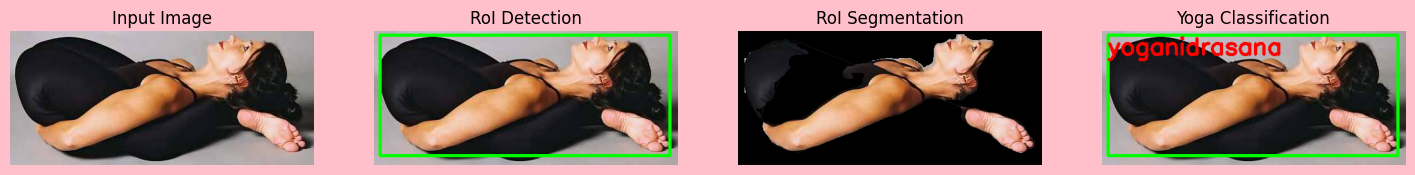

In [9]:
title='Yoga Classification'
a, b, c, d = predict(askopenfilename())
Plotting(a, b, c, d,title)